In [1]:
import os, sys, glob
import math
import collections
import copy
import json
import ROOT
import anaConfig
from ROOT import Ana, TCanvas, TH1D, TPad, TLegend, THStack, RDataFrame
from argparse import ArgumentParser

Info in <ACLiC>: unmodified script has already been compiled and loaded


In [2]:
ANA_DIR = os.path.expanduser("/home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana")
os.chdir(ANA_DIR)
sys.path.insert(0, ANA_DIR)

ROOT.gInterpreter.AddIncludePath(ANA_DIR)  
ROOT.gROOT.LoadMacro("Particle.h+")
ROOT.gROOT.LoadMacro("HHbbtautauAnaElements.C+")

print("CWD =", os.getcwd())
print("sys.path[0] =", sys.path[0])

ROOT.gErrorIgnoreLevel = ROOT.kInfo  # show more
# ROOT.ROOT.EnableImplicitMT()         # Enable multithreading
ROOT.ROOT.DisableImplicitMT()

print("CWD =", os.getcwd())
print("sys.path[0] =", sys.path[0])

CWD = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana
sys.path[0] = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana
CWD = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana
sys.path[0] = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana


Warning in <ROOT_TImplicitMT_DisableImplicitMT>: Implicit multi-threading is already disabled


In [3]:
def ls_nanoaod_files_from_fs(
    base_dir,
    sample,
    dataset_tag=None,          # if None: auto-pick if unique, else error w/ choices
    production_id=None,        # if None: pick lexicographically latest (YYMMDD_HHMMSS)
    pattern="*.root",          # adjust if needed (e.g. "nano*.root")
    recursive=True,
    verbose=0,
):
    base_dir = os.path.abspath(base_dir)
    sample_dir = os.path.join(base_dir, sample)
    if not os.path.isdir(sample_dir):
        avail = sorted(
            d for d in os.listdir(base_dir)
            if os.path.isdir(os.path.join(base_dir, d))
        )
        raise FileNotFoundError(
            f"Sample dir not found:\n  {sample_dir}\n"
            f"Available samples under {base_dir}:\n  - " + "\n  - ".join(avail)
        )

    # dataset_tag selection
    dataset_tags = sorted(
        d for d in os.listdir(sample_dir)
        if os.path.isdir(os.path.join(sample_dir, d))
    )
    if not dataset_tags:
        raise FileNotFoundError(f"No dataset_tag dirs under:\n  {sample_dir}")

    if dataset_tag is None:
        if len(dataset_tags) == 1:
            dataset_tag = dataset_tags[0]
        else:
            raise ValueError(
                f"Multiple dataset_tag dirs under:\n  {sample_dir}\n"
                f"Pass dataset_tag=... one of:\n  - " + "\n  - ".join(dataset_tags)
            )
    else:
        if dataset_tag not in dataset_tags:
            raise ValueError(
                f"dataset_tag '{dataset_tag}' not found under:\n  {sample_dir}\n"
                f"Available:\n  - " + "\n  - ".join(dataset_tags)
            )

    dataset_dir = os.path.join(sample_dir, dataset_tag)

    # production_id selection
    prod_ids = sorted(
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d))
    )
    if not prod_ids:
        raise FileNotFoundError(f"No production_id dirs under:\n  {dataset_dir}")

    if production_id is None:
        production_id = prod_ids[-1]   # YYMMDD_HHMMSS => lexicographic sort works
    else:
        if production_id not in prod_ids:
            raise ValueError(
                f"production_id '{production_id}' not found under:\n  {dataset_dir}\n"
                f"Available:\n  - " + "\n  - ".join(prod_ids)
            )

    prod_dir = os.path.join(dataset_dir, production_id)

    # collect files
    if recursive:
        file_glob = os.path.join(prod_dir, "**", pattern)
        files = sorted(glob.glob(file_glob, recursive=True))
    else:
        file_glob = os.path.join(prod_dir, pattern)
        files = sorted(glob.glob(file_glob))

    # basic sanity: keep only real files
    files = [f for f in files if os.path.isfile(f)]

    if verbose:
        print(f"[ls_nanoaod_files_from_fs]")
        print(f"  base_dir      = {base_dir}")
        print(f"  sample        = {sample}")
        print(f"  dataset_tag   = {dataset_tag}")
        print(f"  production_id = {production_id}")
        print(f"  glob          = {file_glob}")
        print(f"  nfiles        = {len(files)}")
        if verbose > 1:
            for f in files[:10]:
                print("   ", f)

    if not files:
        raise FileNotFoundError(
            f"No ROOT files matched.\n"
            f"  prod_dir   = {prod_dir}\n"
            f"  pattern    = {pattern}\n"
            f"  recursive  = {recursive}\n"
            f"Try pattern='*.root' (already default) or pattern='nano*.root' and keep recursive=True."
        )

    return files


def ls_nanoaod_files_many(
    base_dir,
    samples,                    # list[str] OR dict[str, dict(opts)]
    dataset_tag=None,
    production_id=None,
    pattern="*.root",
    recursive=True,
    verbose=0,
    allow_missing=False,
):
    """
    Bulk collect NanoAOD ROOT files for multiple samples.

    samples can be:
      - list of sample names
      - dict: { sample_name: { 'dataset_tag':..., 'production_id':..., 'pattern':... } }
        (per-sample overrides)
    """
    if isinstance(samples, dict):
        sample_names = list(samples.keys())
        per_sample_opts = samples
    else:
        sample_names = list(samples)
        per_sample_opts = {}

    files_by_sample = {}
    all_files = []

    for s in sample_names:
        opts = per_sample_opts.get(s, {})
        try:
            files = ls_nanoaod_files_from_fs(
                base_dir=base_dir,
                sample=s,
                dataset_tag=opts.get("dataset_tag", dataset_tag),
                production_id=opts.get("production_id", production_id),
                pattern=opts.get("pattern", pattern),
                recursive=opts.get("recursive", recursive),
                verbose=verbose,
            )
        except Exception as e:
            if allow_missing:
                if verbose:
                    print(f"[WARN] skipping sample '{s}': {e}")
                continue
            raise

        files_by_sample[s] = files
        all_files.extend(files)

    return files_by_sample, all_files


def ls_nanoaod_files_groups(
    base_dir,
    groups,                     # dict[group_name] = list[str] OR dict[group_name] = dict(sample->opts)
    dataset_tag=None,
    production_id=None,
    pattern="*.root",
    recursive=True,
    verbose=0,
    allow_missing=False,
):
    """
    Collect per-group file lists.
    Returns:
      group_files: dict[group] -> list[str]
      group_files_by_sample: dict[group] -> dict[sample]->list[str]
    """
    group_files = {}
    group_files_by_sample = {}

    for gname, gspec in groups.items():
        by_sample, all_files = ls_nanoaod_files_many(
            base_dir=base_dir,
            samples=gspec,
            dataset_tag=dataset_tag,
            production_id=production_id,
            pattern=pattern,
            recursive=recursive,
            verbose=verbose,
            allow_missing=allow_missing,
        )
        group_files[gname] = all_files
        group_files_by_sample[gname] = by_sample

    return group_files, group_files_by_sample

In [4]:
def dropBranchNames(frame, filename, exclusionlist = []):
	"""
	Writes a list of column (branch) names from a ROOT RDataFrame to a text file,
	excluding any branches whose names contain substrings in the exclusion list.

	Parameters:
		frame         : ROOT.RDataFrame
			The dataframe to extract column names from.
		filename      : str
			The name of the output text file where the column names will be saved.
		exclusionlist : list of str
			List of substrings; any column containing these substrings will be excluded.
	"""
	with open(filename, "w") as file: 
		for name in frame.GetColumnNames(): 
			name = str(name)
			#print("{} {}".format(name, [(excluded in name) for excluded in exclusionlist]))
			if not (any([excluded in name for excluded in exclusionlist])): 
				file.write("{}\n".format(name))


def WriteFile(sample, filename, blacklist, treename = "Events"): 
	sample.Snapshot(treename, filename, Ana.purgeColumns(sample.GetColumnNames(), blacklist))


def generalise(df): 
	return ROOT.ROOT.RDF.AsRNode(df)

In [5]:
FILE_SIZE = 10_000

In [6]:
BASE = os.path.join(
    "/eos/purdue/store/user/arghyara",
    "production",
    "Scouting",
    "NanoAODv15Scouting24",
    "mcscouting_2024"
)

print(f"BASE directory for MC/data: {BASE}")
print(os.listdir(BASE))

# TODO: Add QCD
 
DY = [
  "DYto2L-2Jets_Bin-2J-MLL-50-PTLL-40to100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
  "DYto2L-2Jets_Bin-MLL-50-PTLL-100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
  "DYto2L-2Jets_Bin-MLL-50-PTLL-400_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
  "DYto2L-2Jets_Bin-MLL-50-PTLL-600_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
]

TT = [
  "TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8",
  "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8",
  "TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8",
]

SIG = [
  "GluGluHHto2B2Tau_Par-c2-0p00-kl-0p00-kt-1p00_TuneCP5_13p6TeV_powheg-pythia8",
]

GROUPS = {"DY": DY, "TT": TT, "HHbbtt": SIG}

group_files, _ = ls_nanoaod_files_groups(
    base_dir=BASE,
    groups=GROUPS,
    dataset_tag=None,          # if None: auto-pick if unique, else error w/ choices
    production_id=None,        # if None: pick lexicographically latest (YYMMDD_HHMMSS)
    pattern="*.root",          # adjust if needed (e.g. "nano*.root")
    recursive=True,
    verbose=0,
)

dy_df  = ROOT.RDataFrame("Events", group_files["DY"])
tt_df  = ROOT.RDataFrame("Events", group_files["TT"])
sig_df = ROOT.RDataFrame("Events", group_files["HHbbtt"])

dy_df  = ROOT.RDataFrame("Events", group_files["DY"]).Range(FILE_SIZE)
tt_df  = ROOT.RDataFrame("Events", group_files["TT"]).Range(FILE_SIZE)
sig_df = ROOT.RDataFrame("Events", group_files["HHbbtt"]).Range(FILE_SIZE) 

BASE directory for MC/data: /eos/purdue/store/user/arghyara/production/Scouting/NanoAODv15Scouting24/mcscouting_2024


['DYto2L-2Jets_Bin-2J-MLL-50-PTLL-40to100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-200_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-400_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-600_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'GluGluHHto2B2Tau_Par-c2-0p00-kl-0p00-kt-1p00_TuneCP5_13p6TeV_powheg-pythia8', 'TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8', 'TTto4Q_TuneCP5_13p6TeV_powheg-pythia8', 'TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8']


Warning in <TClass::Init>: no dictionary for class edm::Hash<1> is available
Warning in <TClass::Init>: no dictionary for class edm::ProcessHistory is available
Warning in <TClass::Init>: no dictionary for class edm::ProcessConfiguration is available
Warning in <TClass::Init>: no dictionary for class edm::ParameterSetBlob is available
Warning in <TClass::Init>: no dictionary for class pair<edm::Hash<1>,edm::ParameterSetBlob> is available


In [7]:
import subprocess

XCACHE_PREFIX = "root://xcache.cms.rcac.purdue.edu/"
DASGOCLIENT = "/cvmfs/cms.cern.ch/common/dasgoclient"
SCOUTING_DATA_JSON = "/home/das214/HHtobbtautau/Run3_nano_submission/datasets/Scouting_DATA.json"

with open(SCOUTING_DATA_JSON) as f:
    SCOUTING_DATASETS = json.load(f)

print("Available years:", list(SCOUTING_DATASETS.keys()))
for yr, runs in SCOUTING_DATASETS.items():
    print(f"  {yr}: {list(runs.keys())}")


def das_files(dataset, prefix=XCACHE_PREFIX):
    """Query DAS for file list and prepend XCache prefix for remote access."""
    result = subprocess.run(
        [DASGOCLIENT, "-query", f"file dataset={dataset}"],
        capture_output=True, text=True, check=True,
    )
    files = [prefix + f.strip() for f in result.stdout.strip().split("\n") if f.strip()]
    return sorted(files)


def load_scouting_data(years=None, runs=None):
    """
    Load scouting data files via XCache.

    Parameters:
        years : list of str, e.g. ["2024"] or ["2022", "2023", "2024"]
                If None, loads all years.
        runs  : list of str, e.g. ["Run2024C", "Run2024D"]
                If None, loads all runs within the selected years.

    Returns:
        all_files : list of XCache file paths
        summary   : dict of {run_name: n_files}
    """
    if years is None:
        years = list(SCOUTING_DATASETS.keys())

    all_files = []
    summary = {}
    for yr in years:
        if yr not in SCOUTING_DATASETS:
            print(f"WARNING: year '{yr}' not in JSON, skipping")
            continue
        for run_name, das_path in SCOUTING_DATASETS[yr].items():
            if runs is not None and run_name not in runs:
                continue
            print(f"  Querying DAS: {run_name} -> {das_path} ...")
            files = das_files(das_path)
            summary[run_name] = len(files)
            all_files.extend(files)
            print(f"    -> {len(files)} files")

    print(f"\nTotal files: {len(all_files)}")
    return all_files, summary


Available years: ['2022', '2023', '2024']
  2022: ['Run2022C', 'Run2022D', 'Run2022E', 'Run2022F', 'Run2022G']
  2023: ['Run2023C', 'Run2023D']
  2024: ['Run2024C', 'Run2024D', 'Run2024E', 'Run2024F', 'Run2024G', 'Run2024H', 'Run2024I', 'Run2024J']


In [8]:
YEARS = ["2024"]
RUNS  = None # ["Run2024C"]  # set to None for all runs in the selected years

data_files, data_summary = load_scouting_data(years=YEARS, runs=RUNS)

data_jetmet_df = ROOT.RDataFrame("Events", data_files)
print(f"\nLoaded {len(data_files)} files into RDataFrame")

data_jetmet_df = data_jetmet_df.Range(FILE_SIZE)

  Querying DAS: Run2024C -> /ScoutingPFRun3/Run2024C-ScoutNano-v1/NANOAOD ...
    -> 3817 files
  Querying DAS: Run2024D -> /ScoutingPFRun3/Run2024D-ScoutNano-v1/NANOAOD ...
    -> 4504 files
  Querying DAS: Run2024E -> /ScoutingPFRun3/Run2024E-ScoutNano-v1/NANOAOD ...
    -> 8650 files
  Querying DAS: Run2024F -> /ScoutingPFRun3/Run2024F-ScoutNano-v1/NANOAOD ...
    -> 23910 files
  Querying DAS: Run2024G -> /ScoutingPFRun3/Run2024G-ScoutNano-v1/NANOAOD ...
    -> 31888 files
  Querying DAS: Run2024H -> /ScoutingPFRun3/Run2024H-ScoutNano-v1/NANOAOD ...
    -> 4478 files
  Querying DAS: Run2024I -> /ScoutingPFRun3/Run2024I-ScoutNano-v1/NANOAOD ...
    -> 10164 files
  Querying DAS: Run2024J -> /ScoutingPFRun3/Run2024J-ScoutNano-v1/NANOAOD ...
    -> 1 files

Total files: 87412

Loaded 87412 files into RDataFrame


In [10]:
dy_df = dy_df.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))
tt_df = tt_df.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))
sig_df = sig_df.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))

sig_df = (sig_df
    .Define("genHbb_idx",    "(int)GenDecay.Htob")     # Higgs that decays to bb
    .Define("genHtautau_idx","(int)GenDecay.Htotau")   # Higgs that decays to tautau
    .Define("genHbb_p4",     "Ana::getP4(genHbb_idx, GenPart_pt, GenPart_eta, GenPart_phi, GenPart_mass)")
    .Define("genHtautau_p4", "Ana::getP4(genHtautau_idx, GenPart_pt, GenPart_eta, GenPart_phi, GenPart_mass)")
    .Define("gen_mHH",       "(genHbb_p4 + genHtautau_p4).M()")
    .Define("gen_pt_Hbb",     "genHbb_p4.Pt()")
    .Define("gen_pt_Htautau", "genHtautau_p4.Pt()")
    .Define("gen_eta_Hbb",     "genHbb_p4.Eta()")
    .Define("gen_eta_Htautau", "genHtautau_p4.Eta()")
)

dy_df = dy_df.Define("w", "genWeight")
tt_df = tt_df.Define("w", "genWeight")
sig_df = sig_df.Define("w", "genWeight")

In [11]:
# REAL DATA
data_jetmet_df = (data_jetmet_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)


# Bkg mc samples
dy_df = (dy_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)

tt_df = (tt_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)

# Signal mc samples
sig_df = (sig_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)

In [12]:
DST_MU_BIT = [
    "DST_PFScouting_DatasetMuon",
    "DST_PFScouting_DoubleMuon",
    "DST_PFScouting_SingleMuon",
]

DST_EL_BITS = [
    "DST_PFScouting_DoubleEG",
    "DST_PFScouting_SinglePhotonEB",
]

DST_JetHT_BITS = [
    "DST_PFScouting_JetHT"
]


def or_expr(bits):
    return "(" + " || ".join(bits) + ")"


DST_MU_expr = or_expr(DST_MU_BIT)
DST_EL_expr = or_expr(DST_EL_BITS)
DST_JetHT_expr = or_expr(DST_JetHT_BITS)

In [13]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep


def th1_to_np(h):
    nb = h.GetNbinsX()
    edges = np.array([h.GetXaxis().GetBinLowEdge(1 + i) for i in range(nb)] + [h.GetXaxis().GetBinUpEdge(nb)], dtype=float)
    vals  = np.array([h.GetBinContent(1 + i) for i in range(nb)], dtype=float)
    errs  = np.array([h.GetBinError(1 + i)   for i in range(nb)], dtype=float)
    return edges, vals, errs

def teff_to_np(teff):
    htot = teff.GetTotalHistogram()  # TH1
    nb = htot.GetNbinsX()
    x = []
    y = []
    yerr_lo = []
    yerr_hi = []
    xerr = []
    for i in range(1, nb + 1):
        tot = htot.GetBinContent(i)
        if tot <= 0:
            continue  # skip empty denominator bins
        xc = htot.GetXaxis().GetBinCenter(i)
        hw = 0.5 * htot.GetXaxis().GetBinWidth(i)
        eff = teff.GetEfficiency(i)
        elo = teff.GetEfficiencyErrorLow(i)
        ehi = teff.GetEfficiencyErrorUp(i)

        eff = float(np.clip(eff, 0.0, 1.0))
        elo = float(np.clip(elo, 0.0, 1.0))
        ehi = float(np.clip(ehi, 0.0, 1.0))
        
        x.append(xc); xerr.append(hw)
        y.append(eff); yerr_lo.append(elo); yerr_hi.append(ehi)
    return (np.array(x), np.array(y), np.array(xerr),
            np.array(yerr_lo), np.array(yerr_hi))

from matplotlib.lines import Line2D

def plot_trigger_eff_overlay_channels(
    channels, triggers, *,
    var="gen_mHH", weight="w", pre_expr=None,
    nbins=20, xmin=200.0, xmax=1800.0,
    cms_year="2024", cms_com="13.6", cms_label_text="",
    figsize=(10, 10),
    pre_label="Preselection", trigger_colors=None,
    pre_key="pre",
    pre_color=None,
    xlabel=None,
):
    """
    channels: list of dicts like
      [
        {"key":"hh", "label":"HH→bbτhτh", "df":sig_df_hh, "ls":"-",  "marker":"o"},
        {"key":"hm", "label":"HH→bbτeτh", "df":sig_df_hm, "ls":"--", "marker":"s"},
        {"key":"he", "label":"HH→bbτμτh", "df":sig_df_he, "ls":":",  "marker":"^"},
      ]

    triggers: list of dicts like
      [
        {"key":"all", "expr": DST_ALL_expr, "label":"Data Scouting", "lw":2.5},
        {"key":"nom", "expr": NOM_expr,     "label":"Nominal",      "lw":2.5},
        {"key":"park","expr": PARK_expr,    "label":"Data Parking", "lw":2.5},
      ]
    """

    # --- assign a stable color per trigger key (and for pre) ---
    if trigger_colors is None: trigger_colors = {}
    trig_keys = [pre_key] + [t["key"] for t in triggers]
    color_map = {}

    if trigger_colors is None:
        trigger_colors = {}

    # default palette (only used if not provided)
    color_map = {
        pre_key:  trigger_colors.get(pre_key,  "tab:blue"),
    }
    for t in triggers:
        k = t["key"]
        color_map[k] = trigger_colors.get(k, {
            "nom":"tab:orange",
            "park":"tab:green",
            "all":"tab:red",
        }.get(k, "black"))

    # --- book ALL hist actions (all channels, all triggers) ---
    h_pre_ptrs = []                   # one per channel
    h_num_ptrs = {t["key"]: [] for t in triggers}  # list per trigger key, one per channel

    for i, ch in enumerate(channels):
        df = ch["df"]
        df_pre = df if (pre_expr is None or str(pre_expr).strip() in ["", "1"]) else df.Filter(pre_expr)

        h_pre_ptrs.append(
            df_pre.Histo1D((f"h_pre_{i}", f";{var} [GeV];Events", nbins, xmin, xmax), var, weight)
        )
        for t in triggers:
            k = t["key"]
            h_num_ptrs[k].append(
                df_pre.Filter(t["expr"]).Histo1D((f"h_{k}_{i}", f";{var} [GeV];Events", nbins, xmin, xmax), var, weight)
            )

    # run once
    all_ptrs = []
    all_ptrs.extend(h_pre_ptrs)
    for k in h_num_ptrs:
        all_ptrs.extend(h_num_ptrs[k])
    try:
        ROOT.RDF.RunGraphs(all_ptrs)
    except Exception:
        pass

    # --- materialize + TEff + numpy per channel ---
    per_ch = []
    for i, ch in enumerate(channels):
        Hpre = h_pre_ptrs[i].GetValue()

        Hnums = {t["key"]: h_num_ptrs[t["key"]][i].GetValue() for t in triggers}

        effs = {}
        for t in triggers:
            k = t["key"]
            te = ROOT.TEfficiency(Hnums[k], Hpre)
            te.SetUseWeightedEvents(True)
            effs[k] = te

        edges, pre_vals, pre_errs = th1_to_np(Hpre)
        num_np = {k: th1_to_np(Hnums[k])[1:] for k in Hnums}  # (vals, errs)
        eff_np = {k: teff_to_np(effs[k]) for k in effs}

        per_ch.append({
            "key": ch.get("key", f"ch{i}"),
            "label": ch.get("label", f"ch{i}"),
            "ls": ch.get("ls", "-"),
            "marker": ch.get("marker", "o"),
            "edges": edges,
            "pre": (pre_vals, pre_errs),
            "num": num_np,
            "eff_np": eff_np,
            "Hpre": Hpre,
            "Hnums": Hnums,
            "effs": effs,
        })

    # --- plot: ONE figure, overlay everything ---
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax  = fig.add_subplot(gs[0])
    rax = fig.add_subplot(gs[1], sharex=ax)

    # TOP: pre + trigger shapes, linestyle by channel, color by trigger
    for ch in per_ch:
        edges = ch["edges"]
        pre_vals, _ = ch["pre"]
        ax.step(
            edges, np.r_[pre_vals, pre_vals[-1]],
            where="post",
            linewidth=2.5,
            linestyle=ch["ls"],
            color=color_map[pre_key],
        )
        for t in triggers:
            k = t["key"]
            vals, _errs = ch["num"][k]
            ax.step(
                edges, np.r_[vals, vals[-1]],
                where="post",
                linewidth=float(t.get("lw", 2.5)),
                linestyle=ch["ls"],
                color=color_map[k],
            )

    ax.set_ylabel("Yields")  # change text if you want
    ax.tick_params(labelbottom=False)
    hep.cms.label(cms_label_text, data=False, ax=ax, year=str(cms_year), com=str(cms_com))

    # BOTTOM: efficiencies, marker by channel, color by trigger
    for ch in per_ch:
        for t in triggers:
            k = t["key"]
            x, y, xerr, ylo, yhi = ch["eff_np"][k]
            rax.errorbar(
                x, y,
                xerr=xerr,
                yerr=np.vstack([ylo, yhi]),
                fmt=ch["marker"],
                markersize=float(t.get("markersize", 5.0)),
                capsize=2,
                linewidth=1.2,
                linestyle="none",
                color=color_map[k],
            )

    rax.set_xlabel(xlabel if xlabel is not None else rf"{var} [GeV]")
    rax.set_ylabel("Trigger Efficiency")
    rax.set_ylim(0.0, 1.1)
    rax.grid(True, axis="y", alpha=0.3)

    # --- two legends: channels (styles) and triggers (colors) ---
    channel_handles = [
        Line2D([0], [0], color="black", linestyle=ch.get("ls","-"), marker=ch.get("marker","o"),
               markersize=6, linewidth=2, label=ch.get("label", ch.get("key","ch")))
        for ch in channels
    ]

    trigger_handles = [Line2D([0],[0], color=color_map[pre_key], linestyle="-", linewidth=2.5, label=pre_label)]
    trigger_handles += [
        Line2D([0],[0], color=color_map[t["key"]], linestyle="-", linewidth=float(t.get("lw",2.5)), label=t.get("label", t["key"]))
        for t in triggers
    ]

    leg1 = ax.legend(handles=channel_handles, title="Decay channels", loc="upper left", frameon=True)
    ax.add_artist(leg1)
    ax.legend(handles=trigger_handles, loc="upper right", frameon=True)

    out = {"per_channel": per_ch, "color_map": color_map}
    return fig, ax, rax, out


In [14]:
plt.style.use(hep.style.CMS)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})


In [15]:
PARKING_HH_BITS = [
	"HLT_PFHT280_QuadPFJet30",
	"HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p55",
	"HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p60",
	"HLT_PFHT280_QuadPFJet35_PNet2BTagMean0p60",
	"HLT_PFHT330PT30_QuadPFJet_75_60_45_40",
	"HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepJet_4p5",
	"HLT_PFHT340_QuadPFJet70_50_40_40_PNet2BTagMean0p70",
	"HLT_PFHT400_SixPFJet32",
	"HLT_PFHT400_SixPFJet32_PNet2BTagMean0p50",
	"HLT_PFHT450_SixPFJet36",
	"HLT_PFHT450_SixPFJet36_PNetBTag0p35",
]

PARKING_MUON_BITS_2023 = [
	"HLT_Dimuon0_Jpsi3p5_Muon2",
	"HLT_Dimuon0_Jpsi_NoVertexing",
	"HLT_Dimuon0_Jpsi_NoVertexing_NoOS",
	"HLT_Dimuon0_LowMass",
	"HLT_Dimuon0_Upsilon_L1_4p5er2p0",
	"HLT_Dimuon0_Upsilon_NoVertexing",
	"HLT_Dimuon10_Upsilon_y1p4",
	"HLT_Dimuon12_Upsilon_y1p4",
	"HLT_Dimuon14_Phi_Barrel_Seagulls",
	"HLT_Dimuon14_PsiPrime",
	"HLT_Dimuon18_PsiPrime",
	"HLT_Dimuon18_PsiPrime_noCorrL1",
	"HLT_Dimuon24_Phi_noCorrL1",
	"HLT_Dimuon24_Upsilon_noCorrL1",
	"HLT_Dimuon25_Jpsi",
	"HLT_Dimuon25_Jpsi_noCorrL1",
	"HLT_DoubleMu2_Jpsi_DoubleTrk1_Phi1p05",
	"HLT_DoubleMu3_DoubleEle7p5_CaloIdL_TrackIdL_Upsilon",
	"HLT_DoubleMu3_TkMu_DsTau3Mu",
	"HLT_DoubleMu3_Trk_Tau3mu",
	"HLT_DoubleMu3_Trk_Tau3mu_NoL1Mass",
	"HLT_DoubleMu4_3_Bs",
	"HLT_DoubleMu4_3_Displaced_Photon4_BsToMMG",
	"HLT_DoubleMu4_3_Jpsi",
	"HLT_DoubleMu4_3_LowMass",
	"HLT_DoubleMu4_3_Photon4_BsToMMG",
	"HLT_DoubleMu4_JpsiTrkTrk_Displaced",
	"HLT_DoubleMu4_JpsiTrk_Bc",
	"HLT_DoubleMu4_Jpsi_Displaced",
	"HLT_DoubleMu4_Jpsi_NoVertexing",
	"HLT_DoubleMu4_LowMass_Displaced",
	"HLT_DoubleMu4_MuMuTrk_Displaced",
	"HLT_DoubleMu5_Upsilon_DoubleEle3_CaloIdL_TrackIdL",
	"HLT_Mu25_TkMu0_Phi",
	"HLT_Mu30_TkMu0_Psi",
	"HLT_Mu30_TkMu0_Upsilon",
	"HLT_Mu7p5_L2Mu2_Jpsi",
	"HLT_Mu7p5_L2Mu2_Upsilon",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_IsoTau15",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_IsoTau15_Charge1",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_Tau15",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_Tau15_Charge1",
	"HLT_Trimuon5_3p5_2_Upsilon_Muon",
	"HLT_TrimuonOpen_5_3p5_2_Upsilon_Muon",
]

PARKING_ELECTRON_BITS_2023 = [
	"HLT_DoubleEle10_eta1p22_mMax6",
	"HLT_DoubleEle6p5_eta1p22_mMax6",
	"HLT_DoubleEle8_eta1p22_mMax6",
	"HLT_SingleEle8",
	"HLT_SingleEle8_SingleEGL1",
]

PARKING_HH_expr     = or_expr(PARKING_HH_BITS)
PARKING_MU_expr     = or_expr(PARKING_MUON_BITS_2023)
PARKING_EG_expr     = or_expr(PARKING_ELECTRON_BITS_2023)
PARKING_LEPT_expr   = f"({PARKING_MU_expr} || {PARKING_EG_expr})"

In [16]:
from matplotlib.lines import Line2D

def _colset(df):
    return set(str(c) for c in df.GetColumnNames())

def plot_yield_overlay(
    dfs, labels, *,
    var=None,          # common variable (string)
    vars=None,         # optional list of variables, one per df
    weight="w",
    pre_expr=None,
    nbins=20, xmin=200.0, xmax=1800.0,
    cms_year="2024", cms_com="13.6", cms_label_text="Simulation",
    figsize=(10, 7),
    xlabel=None,
    ylabel="Weighted yields",
    density=False,
    logy=False,
):
    if len(dfs) != len(labels): raise ValueError("dfs and labels must have the same length")
    if (var is None) == (vars is None): raise ValueError("Provide exactly one of: var='...' (common) OR vars=[...,...,...] (per-DF).")
    if vars is not None and len(vars) != len(dfs): raise ValueError("vars must have the same length as dfs")

    # pick per-DF variable
    vlist = [var]*len(dfs) if vars is None else list(vars)

    # book hist actions
    h_ptrs = []
    for i, df in enumerate(dfs):
        df_sel = df if (pre_expr is None or str(pre_expr).strip() in ["", "1"]) else df.Filter(pre_expr)

        vname = vlist[i]
        cols = _colset(df_sel)
        if vname not in cols:
            # show a small helpful subset
            sample = sorted(list(cols))[:50]
            raise RuntimeError(
                f'Unknown column "{vname}" for dataset "{labels[i]}". '
                f"First ~50 columns: {sample}"
            )

        h_ptrs.append(
            df_sel.Histo1D(
                (f"h_{i}", f";{vname};Yields", int(nbins), float(xmin), float(xmax)),
                vname, weight
            )
        )

    try:
        ROOT.RDF.RunGraphs(h_ptrs)
    except Exception:
        pass

    fig, ax = plt.subplots(figsize=figsize)

    line_objs = []
    for i, hptr in enumerate(h_ptrs):
        H = hptr.GetValue()
        edges, vals, errs = th1_to_np(H)

        if density:
            bw = np.diff(edges)
            area = float(np.sum(vals * bw))
            if area > 0:
                vals = vals / area
                errs = errs / area

        (ln,) = ax.step(edges, np.r_[vals, vals[-1]], where="post", linewidth=2.5)
        line_objs.append(ln)

    ax.set_xlabel(xlabel if xlabel is not None else rf"{(var if var is not None else 'x')} [arb]")
    ax.set_ylabel("Density" if density else ylabel)
    if logy:
        ax.set_yscale("log")

    hep.cms.label(cms_label_text, data=False, ax=ax, year=str(cms_year), com=str(cms_com))

    ax.legend(line_objs, labels, loc="best", frameon=True)
    return fig, ax

(DST_PFScouting_JetHT)
Data events: 3848
DY yield:    8.72145e+06 ± 4.3e+05
TT yield:    430824 ± 5.94e+03
SIG yield:   448.76 ± 5.82
S/√B (yields): 0.148337
y_hh:y_hm:y_he: 199.62:107.135:142.004

  -> WARNING: Plotting 'DY' - found 1 bin(s) with negative yields. Clipping to 0 for the stack.


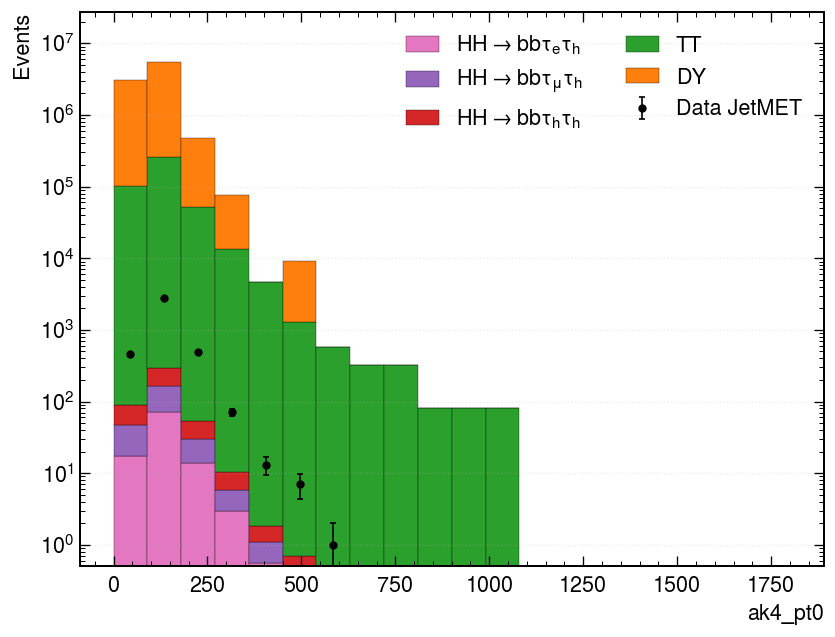

(HLT_PFHT280_QuadPFJet30 || HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p55 || HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p60 || HLT_PFHT280_QuadPFJet35_PNet2BTagMean0p60 || HLT_PFHT330PT30_QuadPFJet_75_60_45_40 || HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepJet_4p5 || HLT_PFHT340_QuadPFJet70_50_40_40_PNet2BTagMean0p70 || HLT_PFHT400_SixPFJet32 || HLT_PFHT400_SixPFJet32_PNet2BTagMean0p50 || HLT_PFHT450_SixPFJet36 || HLT_PFHT450_SixPFJet36_PNetBTag0p35)
Data events: 68
DY yield:    1.92511e+06 ± 1.87e+05
TT yield:    192541 ± 3.98e+03
SIG yield:   192.508 ± 3.83
S/√B (yields): 0.132289
y_hh:y_hm:y_he: 91.1578:42.4911:58.8594

  -> WARNING: Plotting 'DY' - found 1 bin(s) with negative yields. Clipping to 0 for the stack.


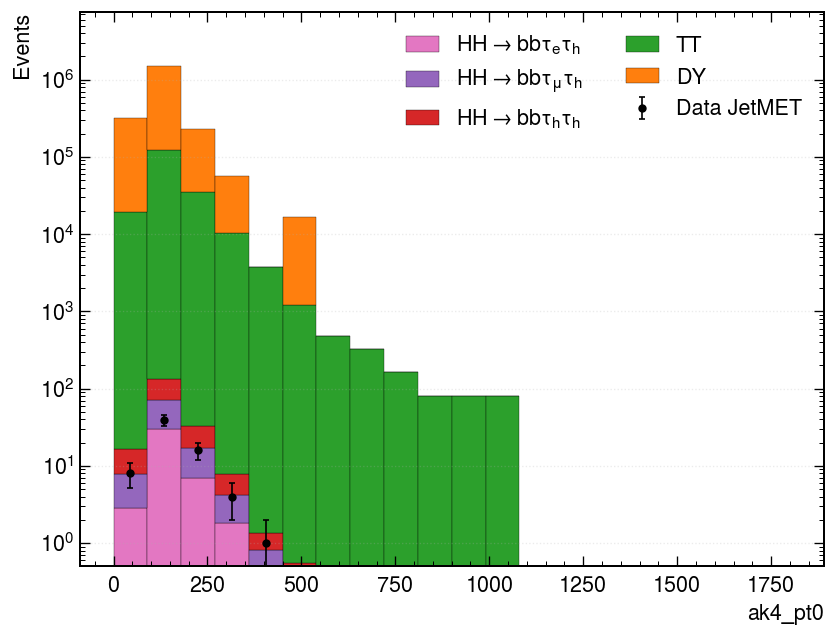

In [17]:
def plot_stacked_all_mc(data_df, mc_items, *,
                        var="ak4_pt0", weight="w",
                        nbins=20, xmin=0, xmax=1800,
                        logy=True,
                        sort_mc_by_yield=True):
    uid = ROOT.TUUID().AsString().replace("-", "_")

    h_data_ptr = data_df.Histo1D((f"h_data_{uid}", f";{var};Events", nbins, xmin, xmax), var)
    h_mc_ptrs = []
    for i, item in enumerate(mc_items):
        h_mc_ptrs.append(
            item["df"].Histo1D((f"h_mc_{i}_{uid}", f";{var};Events", nbins, xmin, xmax), var, weight)
        )

    ROOT.RDF.RunGraphs([h_data_ptr] + h_mc_ptrs)

    edges, data_vals, data_errs = th1_to_np(h_data_ptr.GetValue())
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # Build MC components and sort by total plotted yield (rare -> bottom)
    mc_components = []
    for ptr, item in zip(h_mc_ptrs, mc_items):
        _, vals_raw, _ = th1_to_np(ptr.GetValue())
        
        # --- NEW CODE: Check for negative bins, warn, and clip to 0 ---
        if np.any(vals_raw < 0):
            neg_count = np.sum(vals_raw < 0)
            print(f"  -> WARNING: Plotting '{item['label']}' - found {neg_count} bin(s) with negative yields. Clipping to 0 for the stack.")
        
        vals_clipped = np.maximum(vals_raw, 0.0)
        # --------------------------------------------------------------

        mc_components.append({
            "item": item,
            "vals": vals_clipped, # using the clipped values here
            "yield": float(np.sum(vals_clipped)),
        })

    if sort_mc_by_yield:
        mc_components.sort(key=lambda x: x["yield"])  # ascending: infrequent at bottom

    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros_like(centers, dtype=float)

    for comp in mc_components:
        item = comp["item"]
        vals = comp["vals"]
        ax.bar(
            centers, vals, width=widths, bottom=bottom, align="center",
            label=item["label"], color=item["color"], alpha=1.0, # Switched back to 1.0 for clean stacking
            edgecolor="black", linewidth=0.2
        )
        bottom += vals

    ax.errorbar(
        centers, data_vals, yerr=data_errs, fmt="o", color="black",
        label="Data JetMET", ms=4, capsize=2, linewidth=1, zorder=10
    )

    ax.set_xlabel(var)
    ax.set_ylabel("Events")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(ncol=2)

    if logy:
        ax.set_yscale("log")
        ymax = max(
            float(np.max(bottom)) if len(bottom) else 1.0,
            float(np.max(data_vals)) if len(data_vals) else 1.0
        )
        ax.set_ylim(0.5, max(10.0, 5.0 * ymax))

    return fig, ax


# ----------------------------------------------------------------------------------
# Execution Script
# ----------------------------------------------------------------------------------

base_cut = "ak4_pt0 > 20.0 && ak4_pt1 > 20.0 && ak4_pt2 > 20.0 && ak4_pt3 > 20.0"

data_df_acc = data_jetmet_df.Filter(base_cut)
dy_df_acc   = dy_df.Filter(base_cut)
tt_df_acc   = tt_df.Filter(base_cut)
sig_df_acc  = sig_df.Filter(base_cut)

sig_df_hh = sig_df_acc.Filter("GenDecay.decayType==1")
sig_df_hm = sig_df_acc.Filter("GenDecay.decayType==2")
sig_df_he = sig_df_acc.Filter("GenDecay.decayType==3")

TRIG_LIST = [
DST_JetHT_expr,
PARKING_HH_expr,
]

for trig in TRIG_LIST:
    print("=" * 63)
    print(trig)
    print("=" * 63)

    data_sel = data_df_acc.Filter(trig)
    dy_sel   = dy_df_acc.Filter(trig)
    tt_sel   = tt_df_acc.Filter(trig)
    sig_sel  = sig_df_acc.Filter(trig)

    # data: unweighted event count
    data_n = data_sel.Count().GetValue()

    # MC weighted yields
    dy_y  = dy_sel.Sum("w").GetValue()
    tt_y  = tt_sel.Sum("w").GetValue()
    sig_y = sig_sel.Sum("w").GetValue()

    dy_yerr  = math.sqrt(dy_sel.Define("w2", "w*w").Sum("w2").GetValue())
    tt_yerr  = math.sqrt(tt_sel.Define("w2", "w*w").Sum("w2").GetValue())
    sig_yerr = math.sqrt(sig_sel.Define("w2", "w*w").Sum("w2").GetValue())

    print(f"Data events: {data_n}")
    print(f"DY yield:    {dy_y:.6g} ± {dy_yerr:.3g}")
    print(f"TT yield:    {tt_y:.6g} ± {tt_yerr:.3g}")
    print(f"SIG yield:   {sig_y:.6g} ± {sig_yerr:.3g}")

    hh_sel = sig_sel.Filter("GenDecay.decayType==1")
    hm_sel = sig_sel.Filter("GenDecay.decayType==2")
    he_sel = sig_sel.Filter("GenDecay.decayType==3")

    y_hh = hh_sel.Sum("w").GetValue()
    y_hm = hm_sel.Sum("w").GetValue()
    y_he = he_sel.Sum("w").GetValue()

    if abs(sig_y - (y_hh + y_hm + y_he)) > 1e-6 * max(1.0, abs(sig_y)):
        print("WARNING: yield closure mismatch (float/weights?)")

    B = dy_y + tt_y
    S_over_sqrtB = sig_y / math.sqrt(B) if B > 0 else float("nan")

    print(f"S/√B (yields): {S_over_sqrtB:.6g}")
    print(f"y_hh:y_hm:y_he: {y_hh:.6g}:{y_hm:.6g}:{y_he:.6g}")
    print()

    # unified plot weight so data can be included (unit weight)
    data_plot = data_sel.Define("w_plot", "1.0")
    dy_plot   = dy_sel.Define("w_plot", "w")
    tt_plot   = tt_sel.Define("w_plot", "w")
    sig_plot  = sig_sel.Define("w_plot", "w")

    hh_sel = sig_sel.Filter("GenDecay.decayType==1")
    hm_sel = sig_sel.Filter("GenDecay.decayType==2")
    he_sel = sig_sel.Filter("GenDecay.decayType==3")

    mc_items = [
        {"df": dy_sel, "label": "DY", "color": "tab:orange"},
        {"df": tt_sel, "label": "TT", "color": "tab:green"},
        {"df": hh_sel, "label": r"$HH\to bbτ_hτ_h$", "color": "tab:red"},
        {"df": hm_sel, "label": r"$HH\to bbτ_eτ_h$", "color": "tab:pink"},
        {"df": he_sel, "label": r"$HH\to bbτ_μτ_h$", "color": "tab:purple"},
    ]

    fig, ax = plot_stacked_all_mc(
        data_df=data_sel,
        mc_items=mc_items,
        var="ak4_pt0",
        weight="w",
        nbins=20, xmin=0, xmax=1800,
        logy=True,
    )
    plt.show()